In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV, ElasticNetCV, LinearRegression
# from ngboost import NGBRegressor
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import lasso_path

from utils.utils import PolicyEDA, FeatureEngineering, DataCleaningUtils



/home/tony-ubuntu/anaconda3/envs/cpa_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
eda_utils = PolicyEDA()
dcu = DataCleaningUtils()
fe = FeatureEngineering()

In [4]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
RESULTS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "results")

In [5]:
# Load the emissions data
emissions_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "total_emissions.csv"))
emissions_df.head()

,iso_alpha_3,income_group,region,year,total_emissions
0,ABW,High income,Latin America & Caribbean,2000,0.335765
1,ABW,High income,Latin America & Caribbean,2001,0.344135
2,ABW,High income,Latin America & Caribbean,2002,0.363222
3,ABW,High income,Latin America & Caribbean,2003,0.412246
4,ABW,High income,Latin America & Caribbean,2004,0.430187


In [6]:
emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4485 entries, 0 to 4484
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_alpha_3      4485 non-null   object 
 1   income_group     4485 non-null   object 
 2   region           4485 non-null   object 
 3   year             4485 non-null   int64  
 4   total_emissions  4485 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 175.3+ KB


In [7]:
# Load the wb controls
wb_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "wb_indicators.csv"))
wb_df.head()

,year,pop_total,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd,iso_alpha_3
0,2022,731821393.0,NaN,NaN,29.737205,1.040350e+12,3.196559e+11,2.535995e+11,1.016612e+11,2.360208e+11,NaN
1,2021,713090928.0,4.939318,NaN,29.955194,1.004646e+12,2.769094e+11,2.468588e+11,9.989399e+10,2.143081e+11,NaN
2,2020,694446100.0,4.585792,66.123449,30.174252,9.606813e+11,2.448648e+11,2.363776e+11,9.446765e+10,1.958722e+11,NaN
3,2019,675950189.0,5.173796,63.387090,30.391626,9.890095e+11,2.770649e+11,2.482358e+11,1.014837e+11,2.217922e+11,NaN
4,2018,657801085.0,3.945917,62.242631,30.611512,9.677734e+11,2.838657e+11,2.437429e+11,1.002104e+11,2.275611e+11,NaN


In [8]:
wb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6118 entries, 0 to 6117
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   year                                6118 non-null   int64  
 1   pop_total                           6095 non-null   float64
 2   electricity_from_renewables_pct     5617 non-null   float64
 3   renewable_energy_consumption_pct    5710 non-null   float64
 4   forest_area_pct                     5953 non-null   float64
 5   gdp_2015_usd                        5832 non-null   float64
 6   imports_2015_usd                    4449 non-null   float64
 7   industry_value_added_2015_usd       5254 non-null   float64
 8   manufacturing_value_added_2015_usd  4733 non-null   float64
 9   exports_2015_usd                    4413 non-null   float64
 10  iso_alpha_3                         4945 non-null   object 
dtypes: float64(9), int64(1), object(1)
memory u

In [9]:
indicators_and_emissions_df = pd.merge(emissions_df, wb_df, on=["iso_alpha_3", "year"], how="left")
indicators_and_emissions_df.head()

,iso_alpha_3,income_group,region,year,total_emissions,pop_total,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd
0,ABW,High income,Latin America & Caribbean,2000,0.335765,90588.0,0.0,0.2,2.333333,2.735727e+09,NaN,NaN,NaN,NaN
1,ABW,High income,Latin America & Caribbean,2001,0.344135,91439.0,0.0,0.2,2.333333,2.850135e+09,NaN,NaN,NaN,NaN
2,ABW,High income,Latin America & Caribbean,2002,0.363222,92074.0,0.0,0.2,2.333333,2.823203e+09,NaN,NaN,NaN,NaN
3,ABW,High income,Latin America & Caribbean,2003,0.412246,93128.0,0.0,0.2,2.333333,2.854554e+09,NaN,NaN,NaN,NaN
4,ABW,High income,Latin America & Caribbean,2004,0.430187,95138.0,0.0,0.2,2.333333,3.062758e+09,NaN,NaN,NaN,NaN


In [10]:
## remove unnecessary columns
indicators_and_emissions_df = indicators_and_emissions_df.drop(columns=[
                                                        "income_group",
                                                        "region"
                    ])

# move total_emissions to the end
indicators_and_emissions_df = indicators_and_emissions_df[[col for col in indicators_and_emissions_df.columns if col != "total_emissions"] + ["total_emissions"]]
indicators_and_emissions_df.head()

,iso_alpha_3,year,pop_total,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd,total_emissions
0,ABW,2000,90588.0,0.0,0.2,2.333333,2.735727e+09,NaN,NaN,NaN,NaN,0.335765
1,ABW,2001,91439.0,0.0,0.2,2.333333,2.850135e+09,NaN,NaN,NaN,NaN,0.344135
2,ABW,2002,92074.0,0.0,0.2,2.333333,2.823203e+09,NaN,NaN,NaN,NaN,0.363222
3,ABW,2003,93128.0,0.0,0.2,2.333333,2.854554e+09,NaN,NaN,NaN,NaN,0.412246
4,ABW,2004,95138.0,0.0,0.2,2.333333,3.062758e+09,NaN,NaN,NaN,NaN,0.430187


In [11]:
indicators_and_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4485 entries, 0 to 4484
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_alpha_3                         4485 non-null   object 
 1   year                                4485 non-null   int64  
 2   pop_total                           4462 non-null   float64
 3   electricity_from_renewables_pct     4216 non-null   float64
 4   renewable_energy_consumption_pct    4324 non-null   float64
 5   forest_area_pct                     4402 non-null   float64
 6   gdp_2015_usd                        4317 non-null   float64
 7   imports_2015_usd                    3431 non-null   float64
 8   industry_value_added_2015_usd       4032 non-null   float64
 9   manufacturing_value_added_2015_usd  3743 non-null   float64
 10  exports_2015_usd                    3431 non-null   float64
 11  total_emissions                     4485 no

## In this version we only care about OECD countries

In [12]:
oecd_iso_alpha_3 = eda_utils.get_oecd_iso_codes()
indicators_and_emissions_df = indicators_and_emissions_df[indicators_and_emissions_df["iso_alpha_3"].isin(oecd_iso_alpha_3)]
indicators_and_emissions_df = indicators_and_emissions_df.sort_values(by=["iso_alpha_3", "year"]).reset_index(drop=True)
indicators_and_emissions_df.head()

,iso_alpha_3,year,pop_total,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd,total_emissions
0,AUS,2000,19028802.0,0.585138,8.4,17.158156,8.726517e+11,1.165496e+11,2.059139e+11,8.104095e+10,1.579306e+11,581.422036
1,AUS,2001,19274701.0,0.711866,8.4,17.128633,8.903238e+11,1.154136e+11,2.039505e+11,8.291277e+10,1.715792e+11,602.437642
2,AUS,2002,19495210.0,0.877634,8.7,17.099111,9.257550e+11,1.169708e+11,2.127592e+11,8.519807e+10,1.707368e+11,606.209253
3,AUS,2003,19720737.0,1.062083,7.2,17.069589,9.543678e+11,1.324079e+11,2.253395e+11,8.875237e+10,1.715975e+11,607.749769
4,AUS,2004,19932722.0,1.126409,6.7,17.040066,9.946831e+11,1.502817e+11,2.303904e+11,9.002694e+10,1.738784e+11,608.183791


In [13]:
# Check if we are missing any oecd countries
eda_utils.find_missing_oecd_countries(indicators_and_emissions_df.iso_alpha_3.unique())

set()

In [14]:
indicators_and_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851 entries, 0 to 850
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_alpha_3                         851 non-null    object 
 1   year                                851 non-null    int64  
 2   pop_total                           851 non-null    float64
 3   electricity_from_renewables_pct     814 non-null    float64
 4   renewable_energy_consumption_pct    814 non-null    float64
 5   forest_area_pct                     850 non-null    float64
 6   gdp_2015_usd                        851 non-null    float64
 7   imports_2015_usd                    851 non-null    float64
 8   industry_value_added_2015_usd       829 non-null    float64
 9   manufacturing_value_added_2015_usd  829 non-null    float64
 10  exports_2015_usd                    851 non-null    float64
 11  total_emissions                     851 non-n

## Data Cleaning

In [15]:
# Fill missing values for numeric columns
indicators_and_emissions_df = dcu.fill_numeric_missing_by_group(indicators_and_emissions_df, ["iso_alpha_3"])

In [16]:
indicators_and_emissions_df.describe()

,year,pop_total,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd,total_emissions
count,851.00000,8.510000e+02,851.000000,851.000000,851.000000,8.510000e+02,8.510000e+02,8.510000e+02,8.510000e+02,8.510000e+02,851.000000
mean,2011.00000,3.491213e+07,10.439311,19.481669,35.006019,1.212298e+12,3.071302e+11,2.775024e+11,1.725056e+11,3.035282e+11,396.418943
std,6.63715,5.607785e+07,11.909584,15.979310,17.838481,2.856413e+12,4.543162e+11,5.778710e+11,3.713483e+11,3.923726e+11,938.577015
min,2000.00000,2.812050e+05,-6.259713,0.700000,0.297556,1.185973e+10,4.939037e+09,2.639563e+09,1.217982e+09,4.071601e+09,-2.667559
25%,2005.00000,5.339244e+06,1.981192,7.900000,22.726305,1.650580e+11,6.392526e+10,3.766319e+10,2.149729e+10,5.958573e+10,48.220840
50%,2011.00000,1.050333e+07,6.085865,15.200000,33.469666,3.531793e+11,1.397031e+11,8.768374e+10,5.182212e+10,1.542562e+11,85.443819
75%,2017.00000,4.742665e+07,15.814286,27.700000,40.029846,1.161148e+12,3.977691e+11,3.125168e+11,1.541383e+11,4.271018e+11,444.286318
max,2022.00000,3.332714e+08,81.557609,82.900000,73.735645,2.144339e+13,3.542496e+12,3.383977e+12,2.123243e+12,2.456083e+12,6318.595153


In [17]:
# Check which rows have negative electricity_from_renewables_pct
indicators_and_emissions_df[indicators_and_emissions_df["electricity_from_renewables_pct"] < 0]

,iso_alpha_3,year,pop_total,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd,total_emissions
156,COL,2018,49024465.0,-1.713818,30.4,53.664245,3.114792e+11,6.871918e+10,8.374226e+10,3.743077e+10,4.731595e+10,299.802068
155,COL,2017,48131078.0,-3.013332,32.2,53.843867,3.036916e+11,6.494864e+10,8.350081e+10,3.688660e+10,4.701396e+10,284.605612
154,COL,2016,47437512.0,-0.916667,30.5,54.041902,2.996187e+11,6.429359e+10,8.533903e+10,3.756900e+10,4.583625e+10,281.236866
153,COL,2015,46969940.0,-2.952924,31.1,54.199784,2.934924e+11,6.665374e+10,8.390785e+10,3.639568e+10,4.593218e+10,270.190933
152,COL,2014,46565429.0,-2.282319,32.1,54.321123,2.850661e+11,6.738210e+10,8.218743e+10,3.568081e+10,4.518303e+10,261.938302
151,COL,2013,46151584.0,-6.259713,32.0,54.442462,2.727931e+11,6.252978e+10,7.949429e+10,3.467855e+10,4.531397e+10,262.021733
138,COL,2000,39089934.0,-0.225986,27.9,56.543939,1.570168e+11,1.958041e+10,4.641478e+10,2.265713e+10,2.488228e+10,262.163999


In [18]:
# Drop rows with negative electricity_from_renewables_pct
indicators_and_emissions_df = indicators_and_emissions_df[indicators_and_emissions_df["electricity_from_renewables_pct"] >= 0]

In [19]:
# Check negative emissions
negative_emissions_df = indicators_and_emissions_df[indicators_and_emissions_df["total_emissions"] < 0]
negative_emissions_df.iso_alpha_3.unique()

array(['LVA'], dtype=object)

In [20]:
# Drop the negative emissions
indicators_and_emissions_df =indicators_and_emissions_df[indicators_and_emissions_df["total_emissions"] >= 0]

In [21]:
# Check for duplicates
duplicates_df = indicators_and_emissions_df[indicators_and_emissions_df.duplicated(subset=["iso_alpha_3", "year"], keep=False)]
duplicates_df = duplicates_df.sort_values(by=["iso_alpha_3", "year"])
print(f"Duplicates: {duplicates_df.shape[0]}")
print(duplicates_df)

Duplicates: 0
Empty DataFrame
Columns: [iso_alpha_3, year, pop_total, electricity_from_renewables_pct, renewable_energy_consumption_pct, forest_area_pct, gdp_2015_usd, imports_2015_usd, industry_value_added_2015_usd, manufacturing_value_added_2015_usd, exports_2015_usd, total_emissions]
Index: []


In [22]:
# Check how many records we have per iso_alpha_3 and create a new df
# with the number of records per iso_alpha_3
iso_alpha_3_counts = indicators_and_emissions_df["iso_alpha_3"].value_counts().reset_index()
iso_alpha_3_counts.columns = ["iso_alpha_3", "count"]
iso_alpha_3_counts = iso_alpha_3_counts.sort_values(by="count", ascending=False)

# how many countries have less than x records?
x = 23
countries_with_less_than_x_records = iso_alpha_3_counts[iso_alpha_3_counts["count"] < x]
print(f"Countries with less than {x} records: {countries_with_less_than_x_records.shape[0]}")
print(countries_with_less_than_x_records)

Countries with less than 23 records: 2
   iso_alpha_3  count
35         LVA     20
36         COL     16


In [23]:
# Remove the countries with less than x records from the indicators_and_emissions_df
countries_to_remove = countries_with_less_than_x_records["iso_alpha_3"].tolist()
indicators_and_emissions_df = indicators_and_emissions_df[~indicators_and_emissions_df["iso_alpha_3"].isin(countries_to_remove)]
indicators_and_emissions_df = indicators_and_emissions_df.reset_index(drop=True)

In [24]:
# Check the max year for every country
max_year_df = indicators_and_emissions_df.groupby("iso_alpha_3")["year"].max().reset_index()
max_year_df.columns = ["iso_alpha_3", "max_year"]
max_year_df = max_year_df.sort_values(by="max_year", ascending=False)
print(max_year_df.max_year.unique())

[2022]


In [25]:
indicators_and_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805 entries, 0 to 804
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_alpha_3                         805 non-null    object 
 1   year                                805 non-null    int64  
 2   pop_total                           805 non-null    float64
 3   electricity_from_renewables_pct     805 non-null    float64
 4   renewable_energy_consumption_pct    805 non-null    float64
 5   forest_area_pct                     805 non-null    float64
 6   gdp_2015_usd                        805 non-null    float64
 7   imports_2015_usd                    805 non-null    float64
 8   industry_value_added_2015_usd       805 non-null    float64
 9   manufacturing_value_added_2015_usd  805 non-null    float64
 10  exports_2015_usd                    805 non-null    float64
 11  total_emissions                     805 non-n

In [26]:
indicators_and_emissions_df.describe()

,year,pop_total,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd,total_emissions
count,805.000000,8.050000e+02,805.000000,805.000000,805.000000,8.050000e+02,8.050000e+02,8.050000e+02,8.050000e+02,8.050000e+02,805.000000
mean,2011.000000,3.555393e+07,10.805791,18.654410,33.902408,1.273806e+12,3.228177e+11,2.912344e+11,1.813485e+11,3.193816e+11,411.174985
std,6.637373,5.735823e+07,12.054856,16.003931,17.714218,2.924896e+12,4.621954e+11,5.911721e+11,3.799045e+11,3.976153e+11,962.439291
min,2000.000000,2.812050e+05,0.000000,0.700000,0.297556,1.185973e+10,4.939037e+09,2.639563e+09,1.217982e+09,4.071601e+09,8.129184
25%,2005.000000,5.378867e+06,2.212972,7.600000,22.604447,1.809566e+11,7.134845e+10,4.013721e+10,2.245184e+10,7.078914e+10,50.192429
50%,2011.000000,1.050333e+07,6.702956,14.100000,33.152085,3.746623e+11,1.619018e+11,9.540193e+10,5.569316e+10,1.715975e+11,85.443819
75%,2017.000000,4.818456e+07,16.282398,24.900000,38.716438,1.198984e+12,4.166795e+11,3.215675e+11,1.631166e+11,4.401310e+11,462.342363
max,2022.000000,3.332714e+08,81.557609,82.900000,73.735645,2.144339e+13,3.542496e+12,3.383977e+12,2.123243e+12,2.456083e+12,6318.595153


In [27]:
# # indicators_and_emissions_df = indicators_and_emissions_df.drop(columns=["poverty_headcount_ratio",
# #                                                                         "annual_freshwater_withdrawals_pct",
# #                                                                         "access_to_electricity_pct",
# #                                                                         "agriculture_value_added_pct",
# #                                                                         "pop_urban_pct",
# #                                                                         "pop_growth",])

# indicators_and_emissions_df = indicators_and_emissions_df.drop(columns=["poverty_headcount_ratio",
#                                                                         "annual_freshwater_withdrawals_pct",
#                                                                         "access_to_electricity_pct",
#                                                                         ])


indicators_and_emissions_df = indicators_and_emissions_df.drop(columns=["pop_total"])

In [28]:
indicators_and_emissions_df.iso_alpha_3.unique().shape

(35,)

## EDA 1

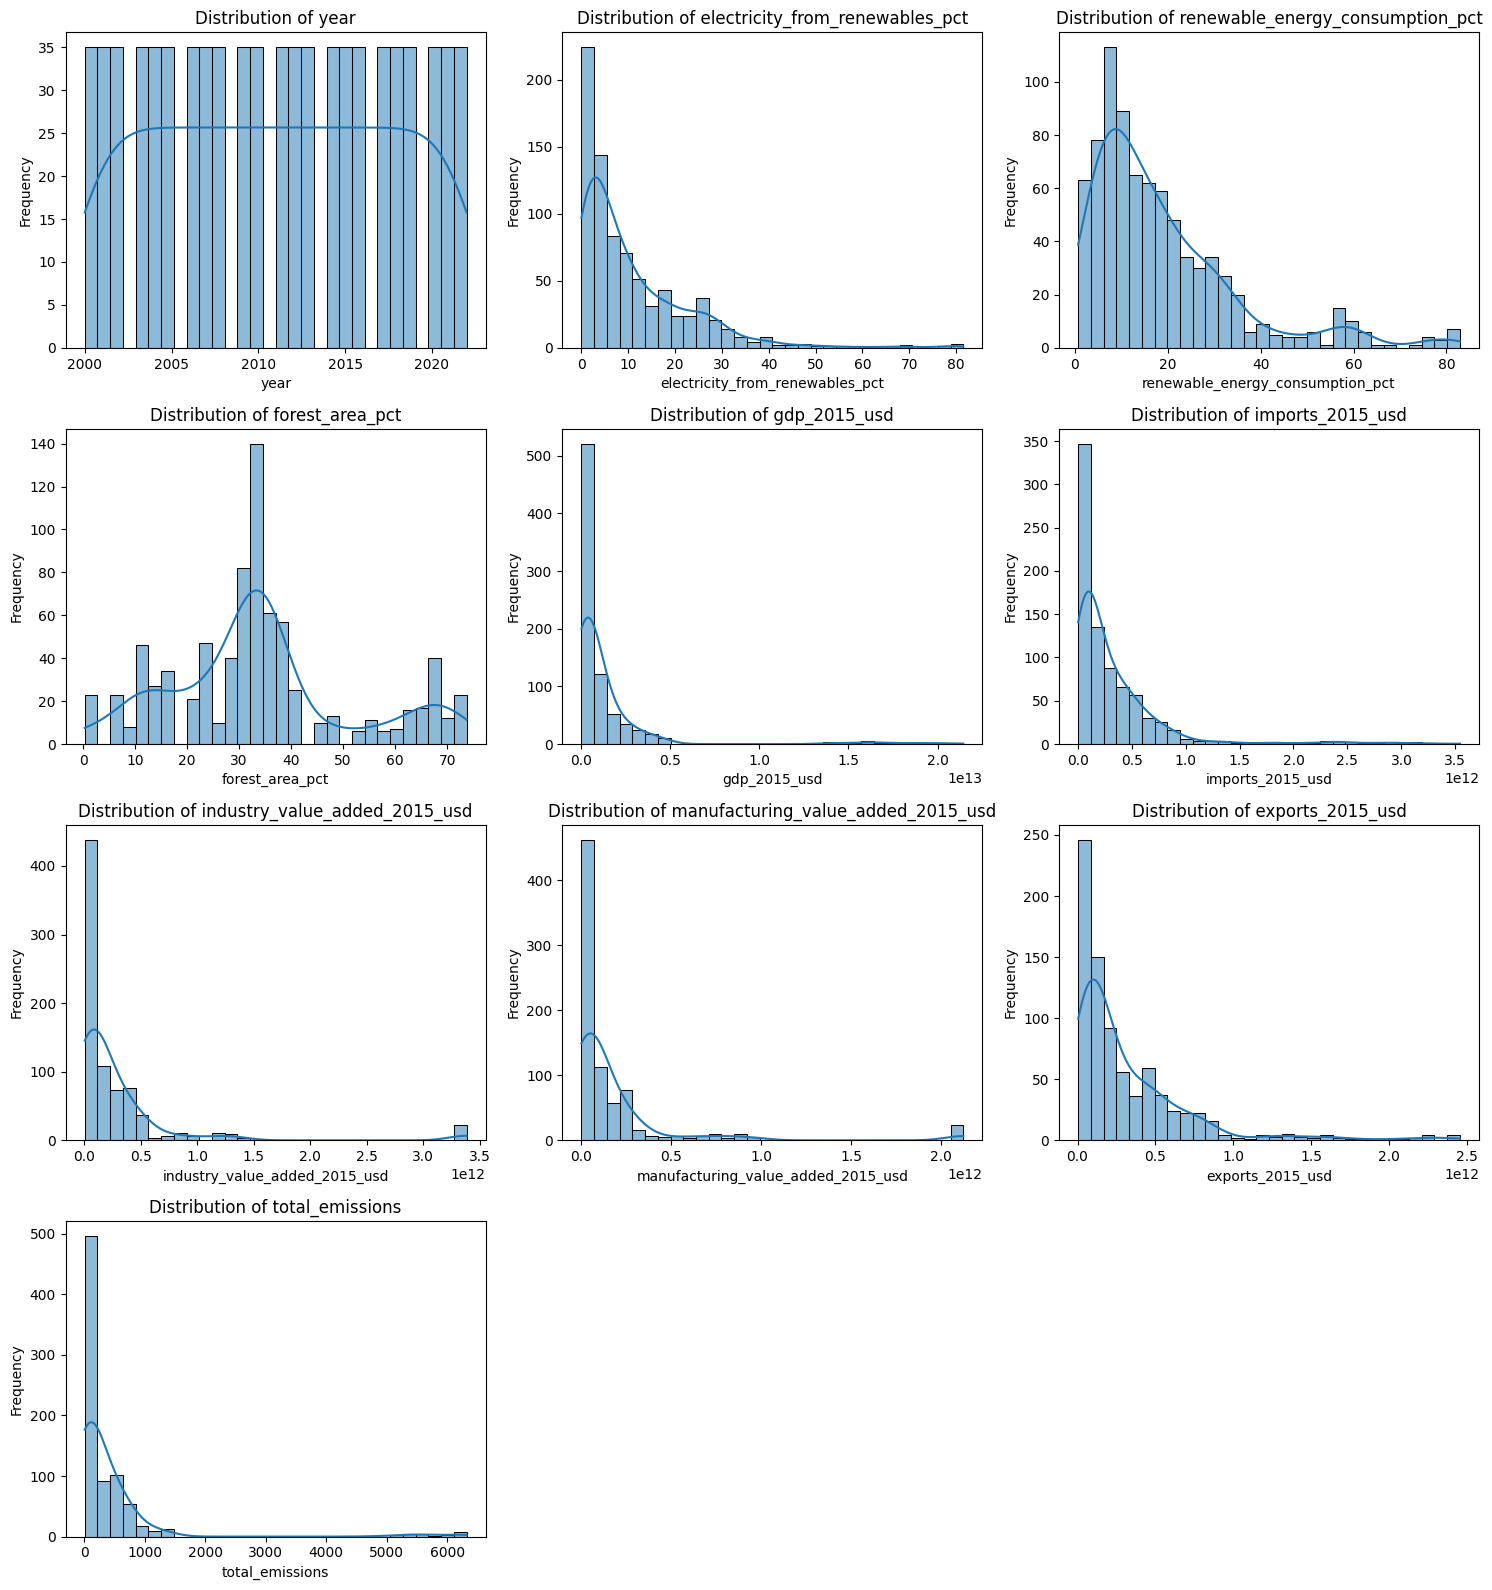

In [29]:
eda_utils.plot_numeric_fields_distributions(indicators_and_emissions_df)

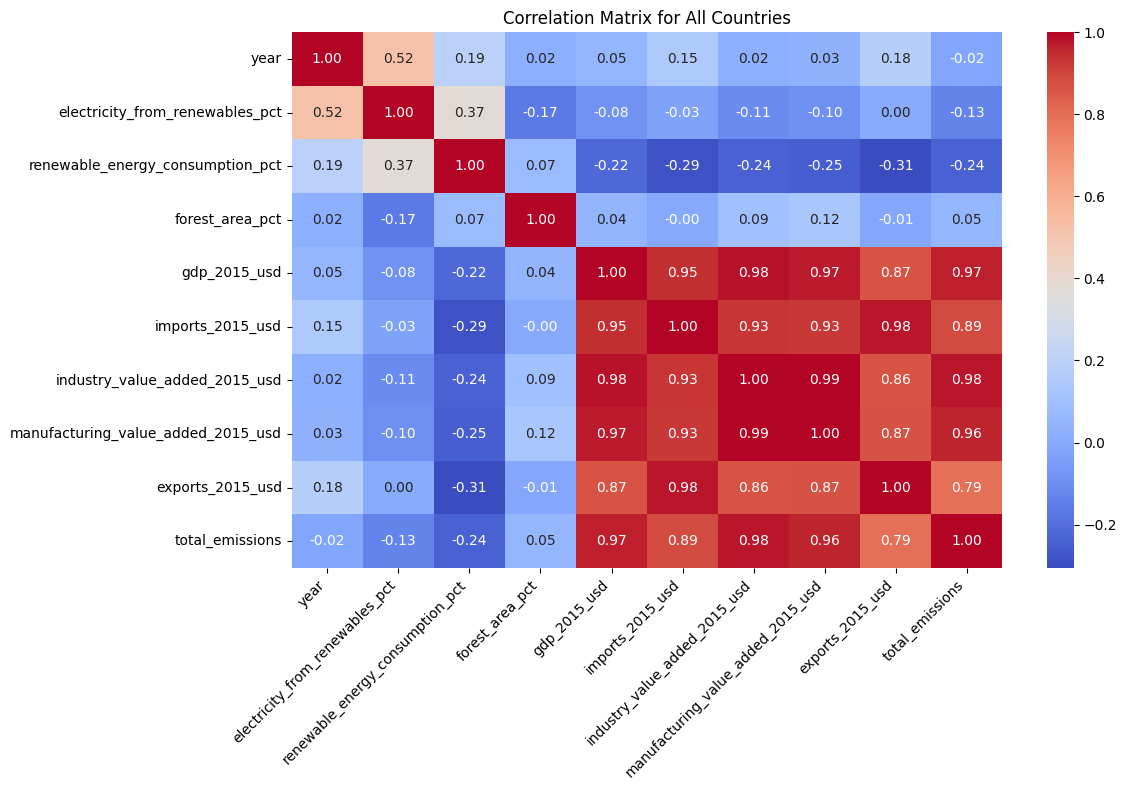

In [30]:
eda_utils.plot_correlation_matrix(indicators_and_emissions_df, figsize=(12,8))

## Feature Engineering for Numeric Features

In [31]:
numeric_cols = indicators_and_emissions_df.select_dtypes(include=["float64", "int64"]).columns.tolist()
numeric_cols_to_drop = ["year"]
numeric_cols = [col for col in numeric_cols if col not in numeric_cols_to_drop]
numeric_cols

['electricity_from_renewables_pct',
 'renewable_energy_consumption_pct',
 'forest_area_pct',
 'gdp_2015_usd',
 'imports_2015_usd',
 'industry_value_added_2015_usd',
 'manufacturing_value_added_2015_usd',
 'exports_2015_usd',
 'total_emissions']

In [32]:
training_df = indicators_and_emissions_df.copy()

In [33]:
training_df_log_transformed = fe.log_transform_high_skew(indicators_and_emissions_df, numeric_cols, skew_threshold=1.0)
training_df_log_transformed.head()

Columns dropped due to high skewness: ['electricity_from_renewables_pct', 'renewable_energy_consumption_pct', 'gdp_2015_usd', 'imports_2015_usd', 'industry_value_added_2015_usd', 'manufacturing_value_added_2015_usd', 'exports_2015_usd', 'total_emissions']


,iso_alpha_3,year,forest_area_pct,log_electricity_from_renewables_pct,log_renewable_energy_consumption_pct,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,log_exports_2015_usd,log_total_emissions
0,AUS,2000,17.158156,0.460671,2.240710,27.494802,25.481583,26.050724,25.118220,25.785422,6.367195
1,AUS,2022,17.421315,0.460671,2.240710,28.092951,26.502725,26.535734,25.169941,26.410877,6.244131
2,AUS,2021,17.421315,3.088191,2.587764,28.051402,26.431968,26.530146,25.145813,26.414388,6.225081
3,AUS,2020,17.421315,2.884104,2.501436,28.030510,26.463199,26.536910,25.128987,26.503297,6.246983
4,AUS,2019,17.421315,2.684873,2.424803,28.031707,26.531130,26.539630,25.148433,26.520527,6.287117


In [34]:
training_df_log_transformed.describe()

,year,forest_area_pct,log_electricity_from_renewables_pct,log_renewable_energy_consumption_pct,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,log_exports_2015_usd,log_total_emissions
count,805.000000,805.000000,805.000000,805.000000,805.000000,805.000000,805.000000,805.000000,805.000000,805.000000
mean,2011.000000,33.902408,1.983780,2.671429,26.709296,25.774950,25.282938,24.721801,25.806633,4.868158
std,6.637373,17.714218,1.028679,0.814316,1.539969,1.285134,1.563043,1.612177,1.281614,1.477090
min,2000.000000,0.297556,0.000000,0.530628,23.196414,22.320436,21.693879,20.920461,22.127302,2.211476
25%,2005.000000,22.604447,1.167196,2.151762,25.921523,24.990841,24.415570,23.834638,24.982971,3.935592
50%,2011.000000,33.152085,2.041604,2.714695,26.649291,25.810256,25.281365,24.743123,25.868417,4.459495
75%,2017.000000,38.716438,2.849689,3.254243,27.812495,26.755583,26.496473,25.817731,26.810338,6.138466
max,2022.000000,73.735645,4.413496,4.429626,30.696437,28.895853,28.850073,28.383966,28.529589,8.751410


In [35]:
training_df_log_transformed.isna().sum()

iso_alpha_3                               0
year                                      0
forest_area_pct                           0
log_electricity_from_renewables_pct       0
log_renewable_energy_consumption_pct      0
log_gdp_2015_usd                          0
log_imports_2015_usd                      0
log_industry_value_added_2015_usd         0
log_manufacturing_value_added_2015_usd    0
log_exports_2015_usd                      0
log_total_emissions                       0
dtype: int64

In [36]:
training_df.isna().sum()

iso_alpha_3                           0
year                                  0
electricity_from_renewables_pct       0
renewable_energy_consumption_pct      0
forest_area_pct                       0
gdp_2015_usd                          0
imports_2015_usd                      0
industry_value_added_2015_usd         0
manufacturing_value_added_2015_usd    0
exports_2015_usd                      0
total_emissions                       0
dtype: int64

## EDA 2

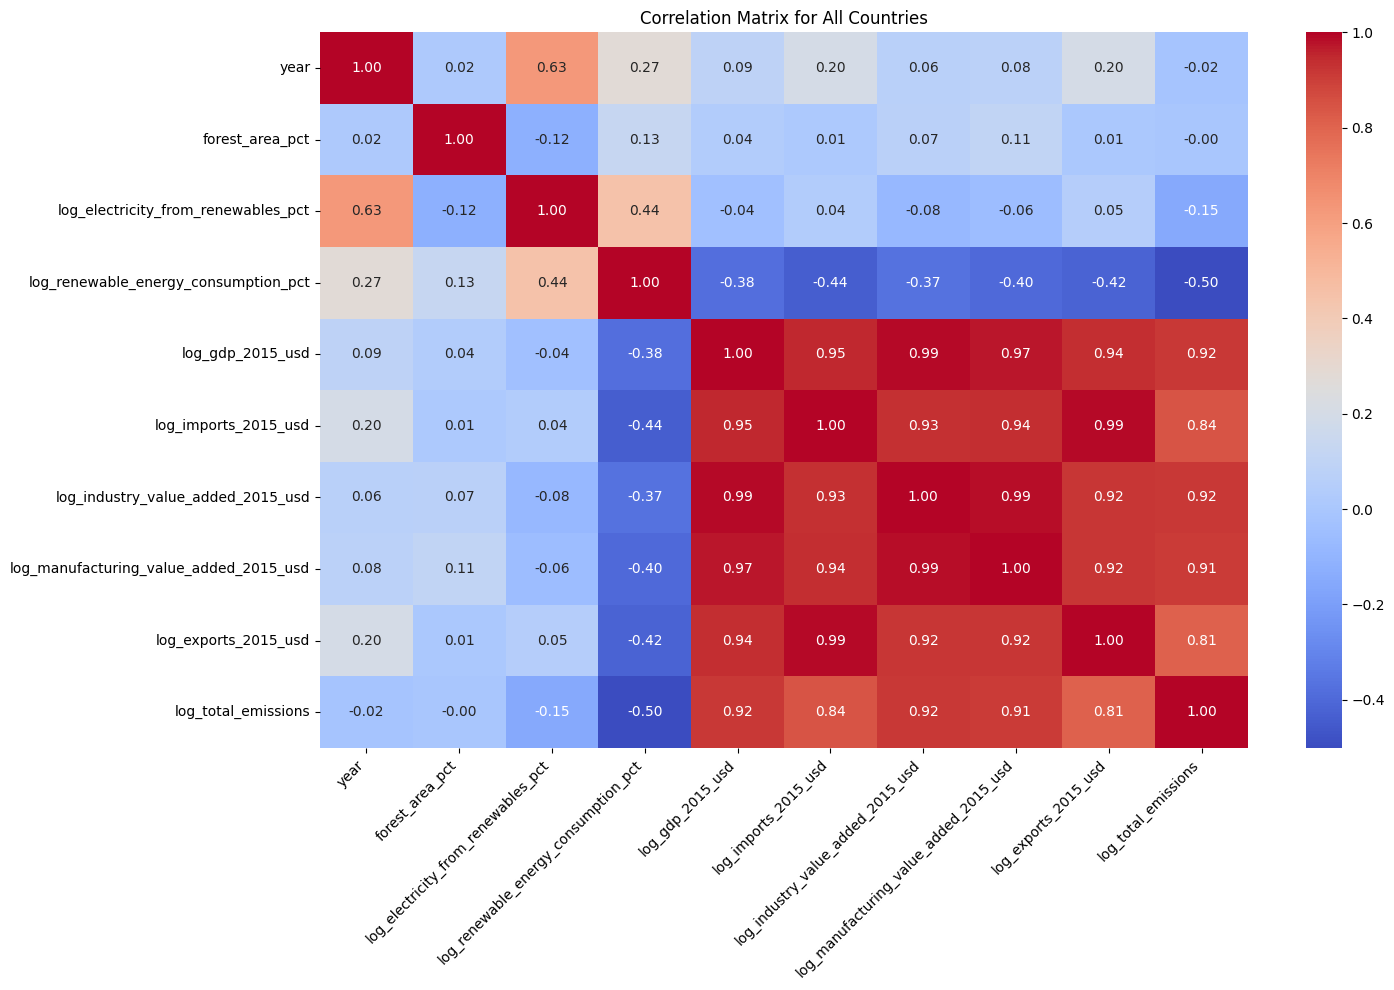

In [37]:
eda_utils.plot_correlation_matrix(training_df_log_transformed, figsize=(15,10))

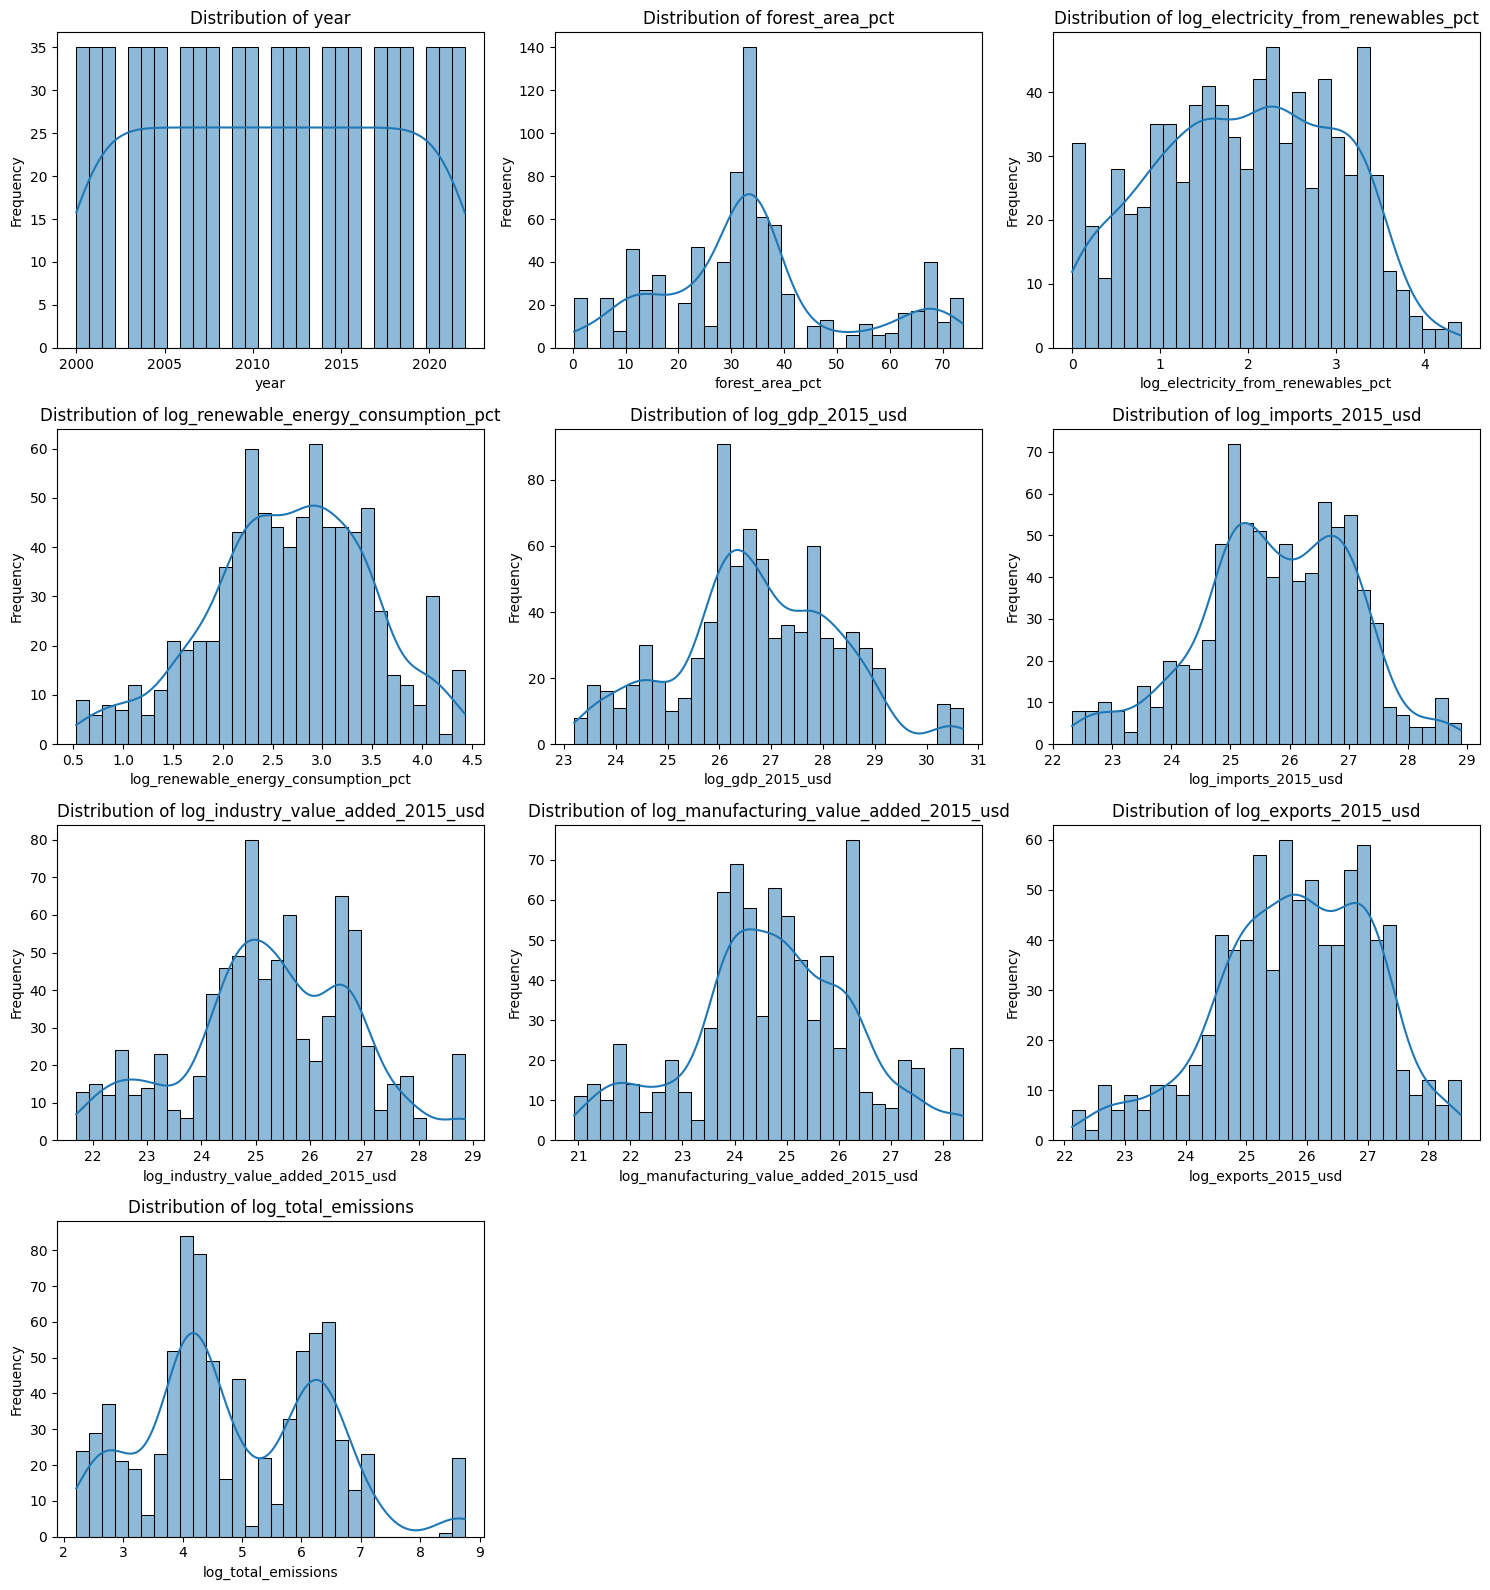

In [38]:
eda_utils.plot_numeric_fields_distributions(training_df_log_transformed)

In [39]:
# def check_for_multicollinearity(df, threshold=0.8, target_col="log_total_emissions"):
#     # Select only numeric columns except 'year'
#     numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
#     if "year" in numeric_cols:
#         numeric_cols.remove("year")
#         numeric_cols.remove(target_col)
#     corr_matrix = df[numeric_cols].corr().abs()
#     to_drop = set()
#     for i in range(len(corr_matrix.columns)):
#         for j in range(i):
#             if corr_matrix.iloc[i, j] >= threshold:
#                 colname = corr_matrix.columns[i]
#                 to_drop.add(colname)
#     print(f"Columns to drop due to multicollinearity (threshold={threshold}): {to_drop}")
#     return list(to_drop)

# check_for_multicollinearity(training_df, threshold=0.8)

In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def remove_high_vif_features(
    df: pd.DataFrame,
    target_col: str,
    exclude_cols: list = ["year"],
    thresh: float = 5.0,
    verbose: bool = True
) -> pd.DataFrame:
    """
    Removes features with high Variance Inflation Factor (VIF) iteratively,
    keeping only numeric columns, excluding year and the target variable.

    Parameters:
    df (pd.DataFrame): Input dataframe.
    target_col (str): Name of the target column (excluded from VIF calc).
    exclude_cols (list): List of additional column names to exclude (e.g., ["year"]).
    thresh (float): VIF threshold above which a feature will be removed.
    verbose (bool): If True, prints VIF info at each iteration.

    Returns:
    pd.DataFrame: DataFrame with selected features and original excluded columns.
    """
    df = df.copy()

    # Identify numeric features excluding target and exclude_cols
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    exclude_cols = set(exclude_cols + [target_col])
    feature_cols = [col for col in numeric_cols if col not in exclude_cols]

    vif_df = df[feature_cols].copy()

    while True:
        X = add_constant(vif_df)
        vif = pd.Series(
            [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
            index=X.columns
        ).drop("const")

        max_vif = vif.max()
        if max_vif > thresh:
            max_vif_feature = vif.idxmax()
            if verbose:
                print(f"Dropping '{max_vif_feature}' with VIF: {max_vif:.2f}")
            vif_df = vif_df.drop(columns=[max_vif_feature])
        else:
            if verbose:
                print("All VIF values are below threshold.")
            break

    # Return original dataframe with reduced features
    return pd.concat([df[list(exclude_cols)], vif_df], axis=1)


training_df_log_and_filtered = remove_high_vif_features(training_df_log_transformed, target_col="log_total_emissions", exclude_cols=["year", "iso_alpha_3"], thresh=5.0, verbose=True)

Dropping 'log_industry_value_added_2015_usd' with VIF: 120.68
Dropping 'log_imports_2015_usd' with VIF: 108.89
Dropping 'log_gdp_2015_usd' with VIF: 25.51
Dropping 'log_exports_2015_usd' with VIF: 8.22
All VIF values are below threshold.


In [41]:
training_df_log_and_filtered.head()

,log_total_emissions,iso_alpha_3,year,forest_area_pct,log_electricity_from_renewables_pct,log_renewable_energy_consumption_pct,log_manufacturing_value_added_2015_usd
0,6.367195,AUS,2000,17.158156,0.460671,2.240710,25.118220
1,6.244131,AUS,2022,17.421315,0.460671,2.240710,25.169941
2,6.225081,AUS,2021,17.421315,3.088191,2.587764,25.145813
3,6.246983,AUS,2020,17.421315,2.884104,2.501436,25.128987
4,6.287117,AUS,2019,17.421315,2.684873,2.424803,25.148433


## ML

In [42]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805 entries, 0 to 804
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_alpha_3                         805 non-null    object 
 1   year                                805 non-null    int64  
 2   electricity_from_renewables_pct     805 non-null    float64
 3   renewable_energy_consumption_pct    805 non-null    float64
 4   forest_area_pct                     805 non-null    float64
 5   gdp_2015_usd                        805 non-null    float64
 6   imports_2015_usd                    805 non-null    float64
 7   industry_value_added_2015_usd       805 non-null    float64
 8   manufacturing_value_added_2015_usd  805 non-null    float64
 9   exports_2015_usd                    805 non-null    float64
 10  total_emissions                     805 non-null    float64
dtypes: float64(9), int64(1), object(1)
memory usa

In [43]:
from typing import List, Tuple, Dict, Any, Optional

def run_regression_analysis(
    df: pd.DataFrame,
    target_col: str,
    group_col: str,
    year_col: str,
    feature_cols: Optional[List[str]] = None,
    holdout_years: int = 5,
    lasso_alphas: np.ndarray = np.logspace(-4, 0, 50),
    enet_alphas: np.ndarray = np.logspace(-4, 0, 50),
    enet_l1_ratio: List[float] = [0.2, 0.5, 0.8],
    rf_params: Dict[str, Any] = None,
    ngb_params: Dict[str, Any] = None,
    plot_feature: str = "log_pop_total"
) -> Dict[str, Any]:
    """
    Run regression analysis with Random Forest, LassoCV, ElasticNetCV, and optionally NGBRegressor.
    Returns a dictionary with results, fitted models, coefficients, and plots.
    """
    # 1. Prepare data
    non_feature_cols = [group_col, year_col, target_col]
    if feature_cols is None:
        feature_cols = [c for c in df.columns if c not in non_feature_cols]
    X = df[feature_cols]
    y = df[target_col]
    groups = df[group_col]
    years = df[year_col]

    # 2. Train/test split (hold out last N years)
    cutoff_year = years.max() - holdout_years
    train_mask = years <= cutoff_year
    X_train = X.loc[train_mask]
    X_test  = X.loc[~train_mask]
    y_train = y.loc[train_mask]
    y_test  = y.loc[~train_mask]
    groups_train = groups.loc[train_mask]

    # 3. Define pipelines
    if rf_params is None:
        rf_params = dict(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
    pipe_rf = Pipeline([
        ("rf", RandomForestRegressor(**rf_params)),
    ])

    pipe_lasso_cv = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", LassoCV(alphas=lasso_alphas, cv=5, random_state=42, n_jobs=-1, max_iter=10000))
    ])

    pipe_enet_cv = Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNetCV(alphas=enet_alphas, l1_ratio=enet_l1_ratio, cv=5, random_state=42, n_jobs=-1, max_iter=10000))
    ])

    # 4. Cross-validation (MAE & R²)
    gkf = GroupKFold(n_splits=5)
    def cv_scores(pipe, scoring):
        return cross_val_score(
            pipe, X_train, y_train, groups=groups_train, cv=gkf, scoring=scoring, n_jobs=-1
        )

    # RF
    rf_mae = -cv_scores(pipe_rf, "neg_mean_absolute_error")
    rf_r2  =  cv_scores(pipe_rf, "r2")
    print(f"Random Forest MAE (CV): {rf_mae}, mean: {rf_mae.mean():.4f}")
    print(f"Random Forest R2 (CV): {rf_r2}, mean: {rf_r2.mean():.4f}")

    # LassoCV
    lasso_mae = -cv_scores(pipe_lasso_cv, "neg_mean_absolute_error")
    lasso_r2  =  cv_scores(pipe_lasso_cv, "r2")
    print(f"LassoCV MAE (CV): {lasso_mae}, mean: {lasso_mae.mean():.4f}")
    print(f"LassoCV R2 (CV): {lasso_r2}, mean: {lasso_r2.mean():.4f}")

    # ElasticNetCV
    enet_mae = -cv_scores(pipe_enet_cv, "neg_mean_absolute_error")
    enet_r2  =  cv_scores(pipe_enet_cv, "r2")
    print(f"ElasticNetCV MAE (CV): {enet_mae}, mean: {enet_mae.mean():.4f}")
    print(f"ElasticNetCV R2 (CV): {enet_r2}, mean: {enet_r2.mean():.4f}")

    # 5. Fit final models on full training set
    pipe_rf.fit(X_train, y_train)
    pipe_lasso_cv.fit(X_train, y_train)
    pipe_enet_cv.fit(X_train, y_train)
   

    # 7. Plot Lasso regularization path for a feature
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    alphas, coefs, _ = lasso_path(X_scaled, y_train, alphas=np.logspace(-4, 0, 100))
    if plot_feature in feature_cols:
        i = feature_cols.index(plot_feature)
        plt.figure()
        plt.plot(alphas, coefs[i], label=plot_feature)
        plt.xscale("log")
        plt.gca().invert_xaxis()
        plt.xlabel("Alpha")
        plt.ylabel("Coefficient")
        plt.title(f"Lasso Path for {plot_feature}")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # 8. Feature importance plot for Random Forest
    importances = pipe_rf.named_steps["rf"].feature_importances_
    indices = np.argsort(importances)[::-1]
    plt.figure(figsize=(8, 6))
    plt.bar(range(len(importances)), importances[indices], align="center")
    plt.xticks(range(len(importances)), [feature_cols[i] for i in indices], rotation=90)
    plt.ylabel("Importance")
    plt.title("Random Forest Feature Importances")
    plt.tight_layout()
    plt.show()

    # Return all relevant objects/results
    pipeline_dict = {
        "rf_pipeline": pipe_rf,
        "lasso_pipeline": pipe_lasso_cv,
        "enet_pipeline": pipe_enet_cv
    }

    return pipeline_dict


Random Forest MAE (CV): [769.4596783  129.02278901 189.9151891   33.16247035 111.96054217], mean: 246.7041
Random Forest R2 (CV): [ 0.16782742  0.52668457 -1.24405428  0.9404502   0.85996923], mean: 0.2502
LassoCV MAE (CV): [370.83774516 121.37415347  64.10965883 102.99786751 189.9579849 ], mean: 169.8555
LassoCV R2 (CV): [0.80797968 0.62781081 0.87333318 0.5781831  0.35549567], mean: 0.6486
ElasticNetCV MAE (CV): [366.72858751 131.29916118  56.68149149  97.53120214 193.23872146], mean: 169.0958
ElasticNetCV R2 (CV): [0.82240038 0.60154923 0.93579964 0.6119671  0.37077494], mean: 0.6685


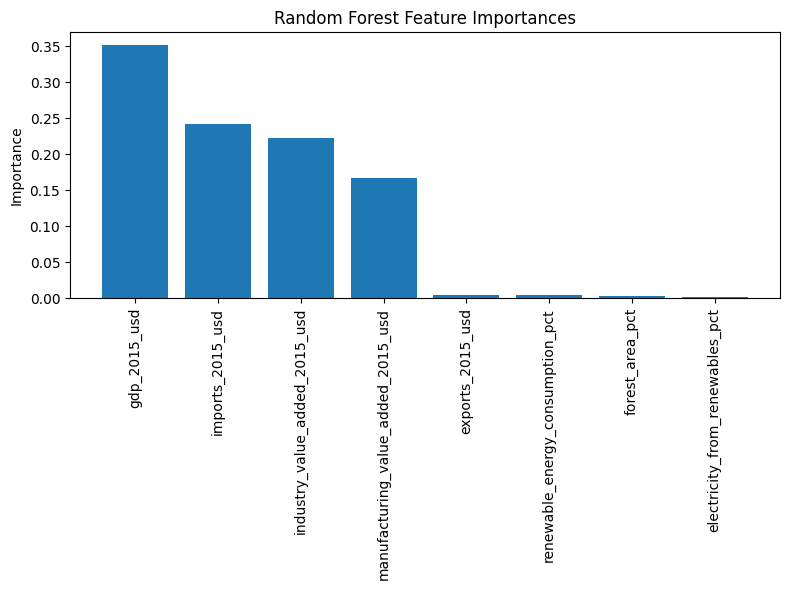

In [44]:
_ = run_regression_analysis(
    df=training_df,
    target_col="total_emissions",
    group_col="iso_alpha_3",
    year_col="year",
    feature_cols=None,
    holdout_years=3,
    lasso_alphas=np.logspace(-4, 0, 50),
    enet_alphas=np.logspace(-4, 0, 50),
    enet_l1_ratio=[0.2, 0.5, 0.8],
    rf_params=dict(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1),
)

Random Forest MAE (CV): [0.66087123 0.62512608 0.46010204 0.40177674 0.589524  ], mean: 0.5475
Random Forest R2 (CV): [0.59041951 0.68736555 0.87328498 0.77257967 0.79661167], mean: 0.7441
LassoCV MAE (CV): [0.32691086 0.68851106 0.36630397 0.25264045 0.4018537 ], mean: 0.4072
LassoCV R2 (CV): [0.91078103 0.70810015 0.88908659 0.90397669 0.86455045], mean: 0.8553
ElasticNetCV MAE (CV): [0.32685636 0.64893333 0.37523734 0.25349385 0.39176701], mean: 0.3993
ElasticNetCV R2 (CV): [0.91076584 0.73293192 0.88670087 0.90296219 0.87392423], mean: 0.8615


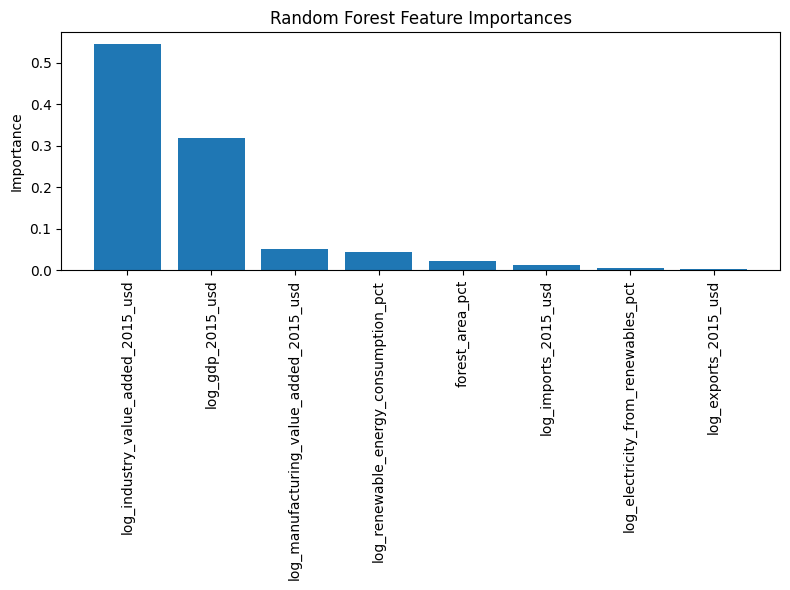

In [45]:
pipeline_dict = run_regression_analysis(
    df=training_df_log_transformed,
    target_col="log_total_emissions",
    group_col="iso_alpha_3",
    year_col="year",
    feature_cols=None,
    holdout_years=3,
    lasso_alphas=np.logspace(-4, 0, 50),
    enet_alphas=np.logspace(-4, 0, 50),
    enet_l1_ratio=[0.2, 0.5, 0.8],
    rf_params=dict(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1),
    ngb_params=dict(n_estimators=500, learning_rate=0.01, verbose=False, random_state=42),
)

Random Forest MAE (CV): [0.82014188 0.72210528 0.36308584 0.44504449 0.88349838], mean: 0.6468
Random Forest R2 (CV): [0.41311265 0.57284491 0.91152062 0.73541334 0.48959066], mean: 0.6245
LassoCV MAE (CV): [0.54489047 0.57818055 0.40362135 0.42589172 0.41564203], mean: 0.4736
LassoCV R2 (CV): [0.77091123 0.7582511  0.84676573 0.72747657 0.84717212], mean: 0.7901
ElasticNetCV MAE (CV): [0.54781536 0.59086934 0.40479414 0.41939368 0.41402583], mean: 0.4754
ElasticNetCV R2 (CV): [0.7692772  0.7489597  0.84785553 0.72907298 0.84877843], mean: 0.7888


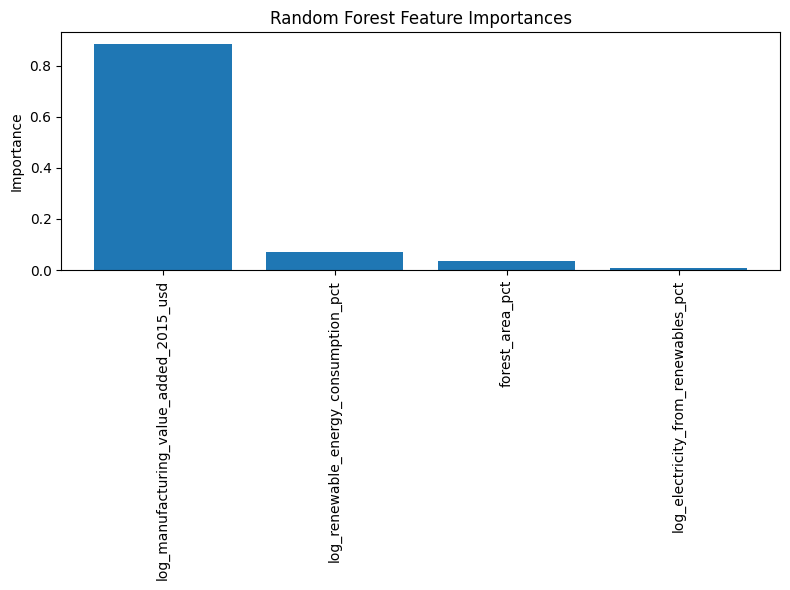

In [46]:
_ = run_regression_analysis(
    df=training_df_log_and_filtered,
    target_col="log_total_emissions",
    group_col="iso_alpha_3",
    year_col="year",
    feature_cols=None,
    holdout_years=3,
    lasso_alphas=np.logspace(-4, 0, 50),
    enet_alphas=np.logspace(-4, 0, 50),
    enet_l1_ratio=[0.2, 0.5, 0.8],
    rf_params=dict(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1),
    ngb_params=dict(n_estimators=500, learning_rate=0.01, verbose=False, random_state=42),
)

## Create projections

In [47]:
from utils.ml_utils import EnsembleProjections
ep = EnsembleProjections()

In [48]:
training_df_log_transformed

,iso_alpha_3,year,forest_area_pct,log_electricity_from_renewables_pct,log_renewable_energy_consumption_pct,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,log_exports_2015_usd,log_total_emissions
0,AUS,2000,17.158156,0.460671,2.240710,27.494802,25.481583,26.050724,25.118220,25.785422,6.367195
1,AUS,2022,17.421315,0.460671,2.240710,28.092951,26.502725,26.535734,25.169941,26.410877,6.244131
2,AUS,2021,17.421315,3.088191,2.587764,28.051402,26.431968,26.530146,25.145813,26.414388,6.225081
3,AUS,2020,17.421315,2.884104,2.501436,28.030510,26.463199,26.536910,25.128987,26.503297,6.246983
4,AUS,2019,17.421315,2.684873,2.424803,28.031707,26.531130,26.539630,25.148433,26.520527,6.287117
...,...,...,...,...,...,...,...,...,...,...,...
800,USA,2001,33.186756,1.053345,1.740466,30.259217,28.168739,28.850073,28.383966,27.847749,8.738518
801,USA,2000,33.130174,1.066065,1.856298,30.249707,28.193661,28.850073,28.383966,27.905189,8.751410
802,USA,2021,33.866926,2.708570,2.476538,30.671624,28.813416,28.850073,28.383966,28.451613,8.537859
803,USA,2010,33.749407,1.624281,2.128232,30.424582,28.474622,28.850073,28.383966,28.271226,8.680793


In [49]:
non_feature_cols = ["iso_alpha_3", "year", "log_total_emissions"]
feature_cols = [col for col in training_df_log_transformed.columns if col not in non_feature_cols]
feature_cols

['forest_area_pct',
 'log_electricity_from_renewables_pct',
 'log_renewable_energy_consumption_pct',
 'log_gdp_2015_usd',
 'log_imports_2015_usd',
 'log_industry_value_added_2015_usd',
 'log_manufacturing_value_added_2015_usd',
 'log_exports_2015_usd']

In [67]:
ensemble_ets_df = ep.generate_ensemble_ts_lhs(
    df=training_df_log_transformed,
    feature_cols=feature_cols,
    start_year=2023,
    end_year=2030,
    n_scenarios=10,
    method="ets",            # or "arima"
    arima_order=(1,1,1),     # only used if method="arima"
    random_state=42
)

ensemble_arima_df = ep.generate_ensemble_ts_lhs(
    df=training_df_log_transformed,
    feature_cols=feature_cols,
    start_year=2023,
    end_year=2030,
    n_scenarios=10,
    method="arima",          # or "ets"
    arima_order=(1,1,1),     # only used if method="arima"
    random_state=42
)


In [68]:
ensemble_ets_df.head()

,iso_alpha_3,future_id,year,forest_area_pct,log_electricity_from_renewables_pct,log_renewable_energy_consumption_pct,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,log_exports_2015_usd
0,AUS,id_AUS_1,2023,17.421315,3.271952,2.316929,28.127805,26.522623,26.537289,25.152198,26.405070
1,AUS,id_AUS_1,2024,17.426013,2.893672,2.343852,28.134277,26.508930,26.543431,25.163330,26.386795
2,AUS,id_AUS_1,2025,17.421407,2.789210,2.323240,28.169075,26.492407,26.596564,25.148443,26.356735
3,AUS,id_AUS_1,2026,17.421315,3.207281,2.339938,28.188283,26.542939,26.552806,25.200171,26.325482
4,AUS,id_AUS_1,2027,17.423311,2.927022,2.318312,28.215816,26.497278,26.560694,25.172443,26.268312


In [69]:
ensemble_ets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 11 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   iso_alpha_3                             2800 non-null   object 
 1   future_id                               2800 non-null   object 
 2   year                                    2800 non-null   int64  
 3   forest_area_pct                         2800 non-null   float64
 4   log_electricity_from_renewables_pct     2800 non-null   float64
 5   log_renewable_energy_consumption_pct    2800 non-null   float64
 6   log_gdp_2015_usd                        2800 non-null   float64
 7   log_imports_2015_usd                    2800 non-null   float64
 8   log_industry_value_added_2015_usd       2800 non-null   float64
 9   log_manufacturing_value_added_2015_usd  2800 non-null   float64
 10  log_exports_2015_usd                    2800 non-null   floa

In [70]:
training_df_log_transformed.head()

,iso_alpha_3,year,forest_area_pct,log_electricity_from_renewables_pct,log_renewable_energy_consumption_pct,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,log_exports_2015_usd,log_total_emissions
0,AUS,2000,17.158156,0.460671,2.240710,27.494802,25.481583,26.050724,25.118220,25.785422,6.367195
1,AUS,2022,17.421315,0.460671,2.240710,28.092951,26.502725,26.535734,25.169941,26.410877,6.244131
2,AUS,2021,17.421315,3.088191,2.587764,28.051402,26.431968,26.530146,25.145813,26.414388,6.225081
3,AUS,2020,17.421315,2.884104,2.501436,28.030510,26.463199,26.536910,25.128987,26.503297,6.246983
4,AUS,2019,17.421315,2.684873,2.424803,28.031707,26.531130,26.539630,25.148433,26.520527,6.287117


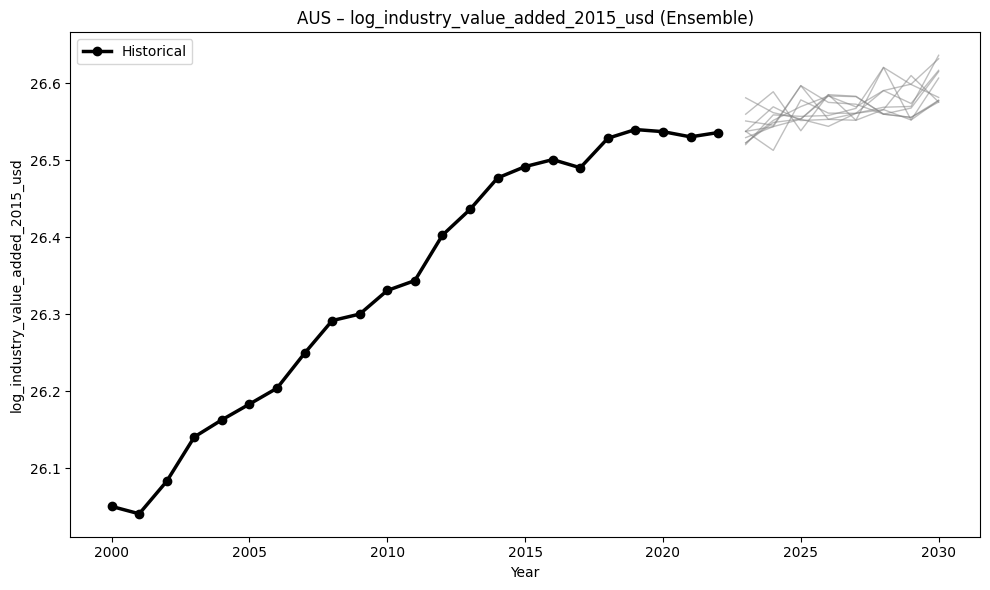

In [71]:
ep.plot_ensemble_time_series(
    df=ensemble_ets_df, 
    iso_alpha_3="AUS",
    column="log_industry_value_added_2015_usd",
    hist_df=training_df_log_transformed)

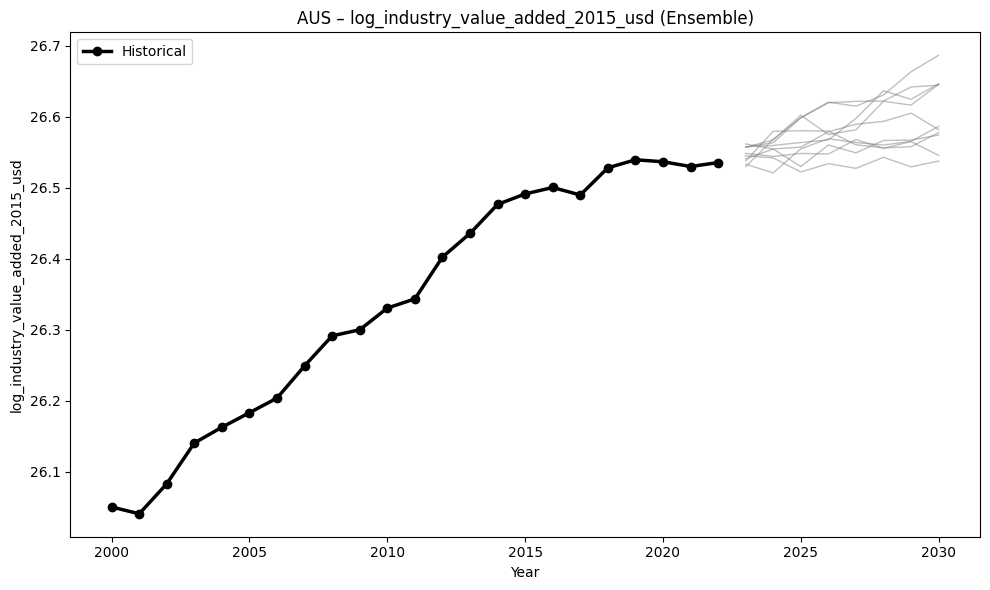

In [75]:
ep.plot_ensemble_time_series(
    df=ensemble_arima_df, 
    iso_alpha_3="AUS",
    column="log_industry_value_added_2015_usd",
    hist_df=training_df_log_transformed)

In [77]:
pipeline_dict.keys()

dict_keys(['rf_pipeline', 'lasso_pipeline', 'enet_pipeline'])

In [81]:
rf_pipeline = pipeline_dict["rf_pipeline"]

In [82]:
ensemble_arima_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 11 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   iso_alpha_3                             2800 non-null   object 
 1   future_id                               2800 non-null   object 
 2   year                                    2800 non-null   int64  
 3   forest_area_pct                         2800 non-null   float64
 4   log_electricity_from_renewables_pct     2800 non-null   float64
 5   log_renewable_energy_consumption_pct    2800 non-null   float64
 6   log_gdp_2015_usd                        2800 non-null   float64
 7   log_imports_2015_usd                    2800 non-null   float64
 8   log_industry_value_added_2015_usd       2800 non-null   float64
 9   log_manufacturing_value_added_2015_usd  2800 non-null   float64
 10  log_exports_2015_usd                    2800 non-null   floa

In [85]:
ensemble_arima_df_with_emissions = ep.predict_ensemble_emissions(ensemble_arima_df, rf_pipeline, feature_cols)
ensemble_arima_df_with_emissions.head()

,iso_alpha_3,future_id,year,forest_area_pct,log_electricity_from_renewables_pct,log_renewable_energy_consumption_pct,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,log_exports_2015_usd,log_total_emissions,total_emissions
0,AUS,id_AUS_1,2023,17.473724,1.418038,2.214923,28.115005,26.568203,26.537933,25.168057,26.401542,6.301635,545.463032
1,AUS,id_AUS_1,2024,17.567790,2.234289,2.115295,28.132269,26.629085,26.579792,25.142274,26.390784,6.296963,542.920776
2,AUS,id_AUS_1,2025,17.641507,1.171139,2.009324,28.150591,26.665751,26.580544,25.126747,26.406168,6.300310,544.740704
3,AUS,id_AUS_1,2026,17.733238,1.212870,1.969326,28.169342,26.744563,26.580035,25.127639,26.404250,6.300087,544.619072
4,AUS,id_AUS_1,2027,17.796681,0.978285,2.125937,28.193298,26.785131,26.560805,25.139929,26.376149,6.282230,534.980096


In [86]:
ensemble_arima_df_with_emissions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   iso_alpha_3                             2800 non-null   object 
 1   future_id                               2800 non-null   object 
 2   year                                    2800 non-null   int64  
 3   forest_area_pct                         2800 non-null   float64
 4   log_electricity_from_renewables_pct     2800 non-null   float64
 5   log_renewable_energy_consumption_pct    2800 non-null   float64
 6   log_gdp_2015_usd                        2800 non-null   float64
 7   log_imports_2015_usd                    2800 non-null   float64
 8   log_industry_value_added_2015_usd       2800 non-null   float64
 9   log_manufacturing_value_added_2015_usd  2800 non-null   float64
 10  log_exports_2015_usd                    2800 non-null   floa

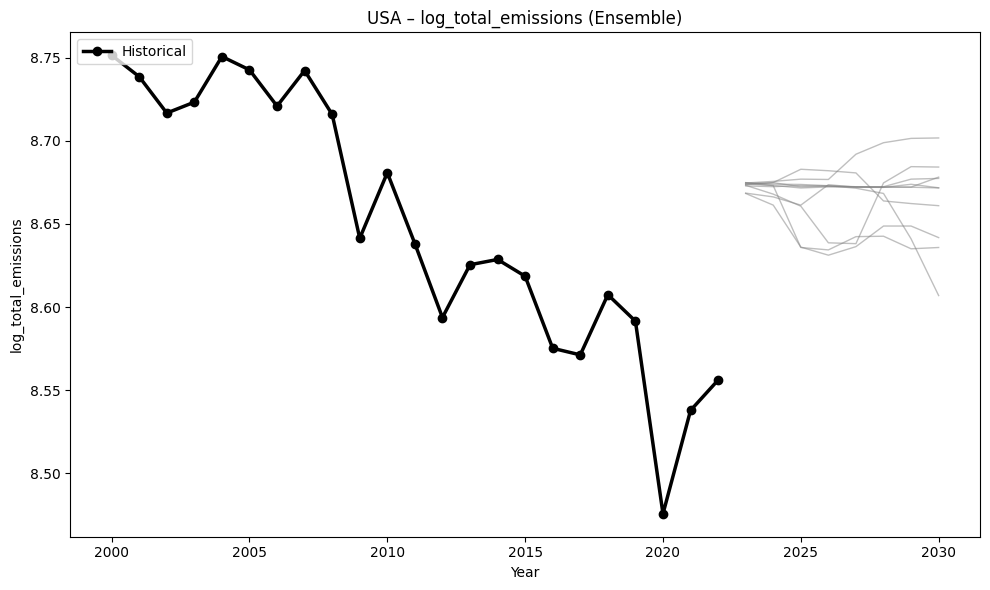

In [90]:
ep.plot_ensemble_time_series(
    df=ensemble_arima_df_with_emissions, 
    iso_alpha_3="USA",
    column="log_total_emissions",
    hist_df=training_df_log_transformed)